<a href="https://colab.research.google.com/github/sarangraje/Data-Science-R/blob/main/Python_Predictive_Modeling_3_diabetes_(new)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("/content/diabetes_dataset_with_notes.csv")
df.drop(columns = "clinical_notes", inplace = True)
df.head()

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

df = pd.get_dummies(df, columns = ["smoking_history", "location", "gender"], drop_first = True)
df.head()

,year,age,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,bmi,...,location_Utah,location_Vermont,location_Virgin Islands,location_Virginia,location_Washington,location_West Virginia,location_Wisconsin,location_Wyoming,gender_Male,gender_Other
0,2020,32.0,0,0,0,0,1,0,0,27.32,...,False,False,False,False,False,False,False,False,False,False
1,2015,29.0,0,1,0,0,0,0,0,19.95,...,False,False,False,False,False,False,False,False,False,False
2,2015,18.0,0,0,0,0,1,0,0,23.76,...,False,False,False,False,False,False,False,False,True,False
3,2015,41.0,0,0,1,0,0,0,0,27.32,...,False,False,False,False,False,False,False,False,True,False
4,2016,52.0,1,0,0,0,0,0,0,23.75,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.shape

(100000, 74)

In [ ]:
df.isna().any().any()

np.False_

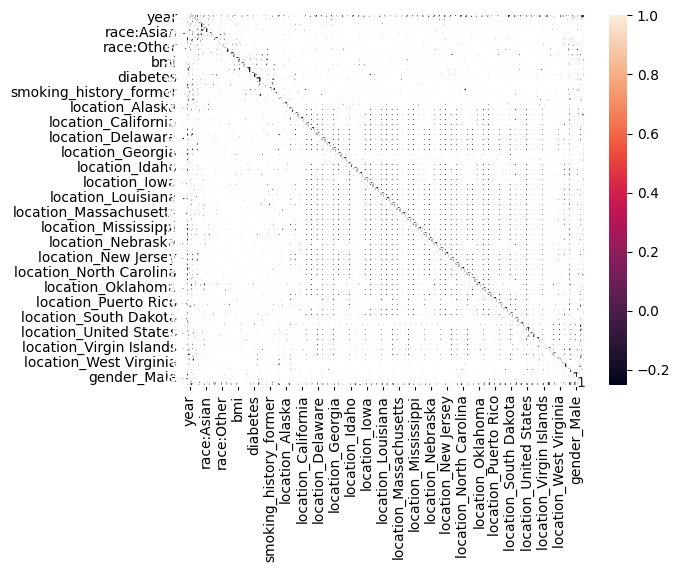

In [ ]:
corr_matrix = df.corr(numeric_only = True)

sns.heatmap(corr_matrix, annot = True)
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df.drop(columns = "diabetes")
y = df["diabetes"]

glm = LogisticRegression()
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state = 31)
glm.fit(X_train, y_train)
y_pred = glm.predict(X_test)

print(accuracy_score(y_test, y_pred), "\n")
print(confusion_matrix(y_test, y_pred), "\n")
print(classification_report(y_test, y_pred), "\n")

0.9601333333333333 

[[27215   230]
 [  966  1589]] 

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     27445
           1       0.87      0.62      0.73      2555

    accuracy                           0.96     30000
   macro avg       0.92      0.81      0.85     30000
weighted avg       0.96      0.96      0.96     30000
 



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


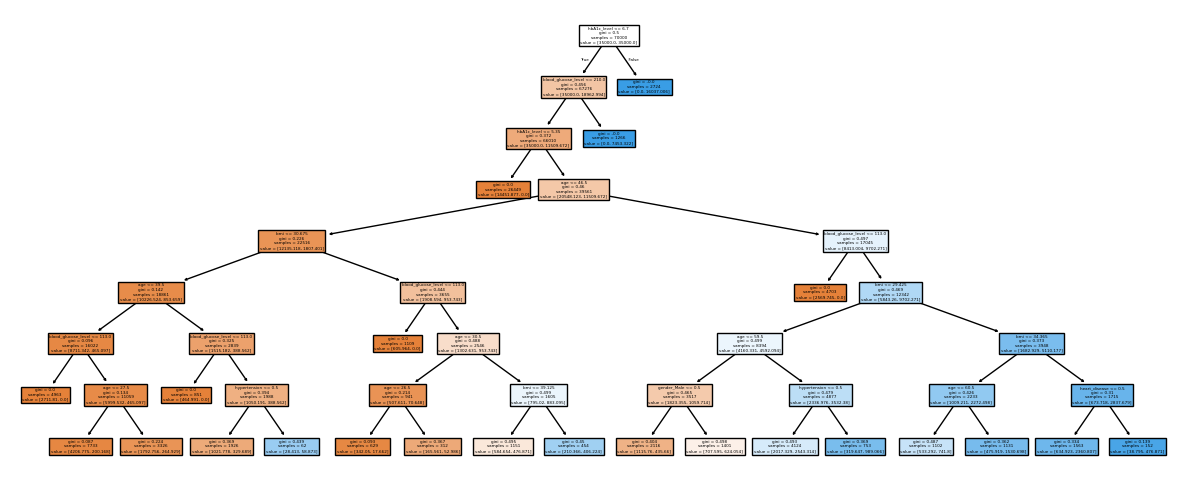

In [ ]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

tr_mod = DecisionTreeClassifier(max_depth = 8, random_state = 31, class_weight = "balanced")
tr_mod.fit(X_train, y_train)
y_pred_tr = tr_mod.predict(X_test)

plt.figure(figsize = (15, 6))
plot_tree(tr_mod, feature_names = X.columns, filled = True)
plt.show()

In [ ]:
print(accuracy_score(y_test, y_pred_tr), "\n")
print(confusion_matrix(y_test, y_pred_tr), "\n")
print(classification_report(y_test, y_pred_tr), "\n")

0.8812333333333333 

[[24097  3348]
 [  215  2340]] 

              precision    recall  f1-score   support

           0       0.99      0.88      0.93     27445
           1       0.41      0.92      0.57      2555

    accuracy                           0.88     30000
   macro avg       0.70      0.90      0.75     30000
weighted avg       0.94      0.88      0.90     30000
 



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_mod = RandomForestClassifier(n_estimators = 500, max_depth = 8, random_state = 31, class_weight = "balanced")
rf_mod.fit(X_train, y_train)
y_pred_rf = rf_mod.predict(X_test)

print(accuracy_score(y_test, y_pred_rf), "\n")
print(confusion_matrix(y_test, y_pred_rf), "\n")
print(classification_report(y_test, y_pred_rf), "\n")

0.9184666666666667 

[[25323  2122]
 [  324  2231]] 

              precision    recall  f1-score   support

           0       0.99      0.92      0.95     27445
           1       0.51      0.87      0.65      2555

    accuracy                           0.92     30000
   macro avg       0.75      0.90      0.80     30000
weighted avg       0.95      0.92      0.93     30000
 



In [ ]:
# Reducing the probability thereshold to catch more sick patients

y_prob_rf = rf_mod.predict_proba(X_test)[:, 1]

y_pred_custom = (y_prob_rf >= 0.4).astype(int)

print("THIS IS THE BEST MODEL!!!", "\n")
print(accuracy_score(y_test, y_pred_custom), "\n")
print(confusion_matrix(y_test, y_pred_custom), "\n")
print(classification_report(y_test, y_pred_custom), "\n")


THIS IS THE BEST MODEL!!! 

0.8594666666666667 

[[23373  4072]
 [  144  2411]] 

              precision    recall  f1-score   support

           0       0.99      0.85      0.92     27445
           1       0.37      0.94      0.53      2555

    accuracy                           0.86     30000
   macro avg       0.68      0.90      0.73     30000
weighted avg       0.94      0.86      0.88     30000
 

